# Class Atoms

SOURCE CODE: [atoms.py](../abtem/atoms.py)

abtem的Atoms对象取自ase中的类。abtem仅拓展其对Atoms对象的操作方法。

In [1]:
import abtem

## 1.ase中Atoms类的实现

SOURCE CODE: ase.atoms.py

- Atoms对象可以表示孤立的分子，也可以表示重复的周期结构，允许在cell的三个轴的任何一个施加边界条件。

- 关于Atoms对象的信息存储在ndarrays里（如atomic numbers，positions）。还允许贮存tags、momenta、masses、magnetic moments和charges等信息。

- 需要提供calculator对象来绑定到atoms对象来实现对于应力、能量等信息的计算。


## 2.Atoms对象的建立


###  2.1 Load from cif


###  2.2 use Atoms()

 N2 molecule (These three are equivalent):
 - 参数法（符号+坐标）
 - 参数法（原子序数+坐标）
 - 列表法 （Atom对象组成列表）

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='z [Å]'>)

d:\miniforge\envs\abtem\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 197 (\N{LATIN CAPITAL LETTER A WITH RING ABOVE}) missing from font(s) SimHei.
  func(*args, **kwargs)
d:\miniforge\envs\abtem\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 197 (\N{LATIN CAPITAL LETTER A WITH RING ABOVE}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


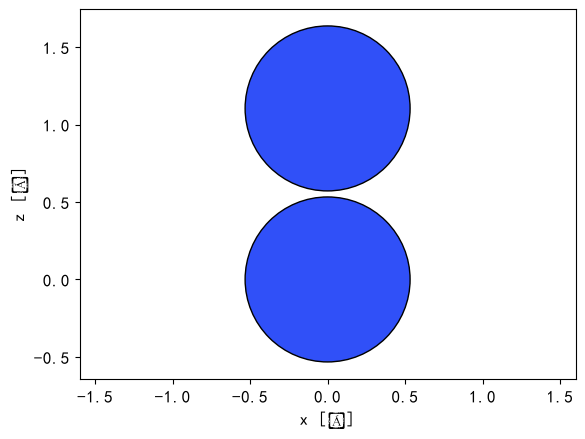

In [2]:
from ase import Atoms, Atom
import abtem
d = 1.104  # N2 bondlength
a = Atoms('N2', [(0, 0, 0), (0, 0, d)])
a = Atoms(numbers=[7, 7], positions=[(0, 0, 0), (0, 0, d)])
a = Atoms([Atom('N', (0, 0, 0)), Atom('N', (0, 0, d))])
abtem.show_atoms(a,plane='xz')

FCC gold:

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='y [Å]'>)

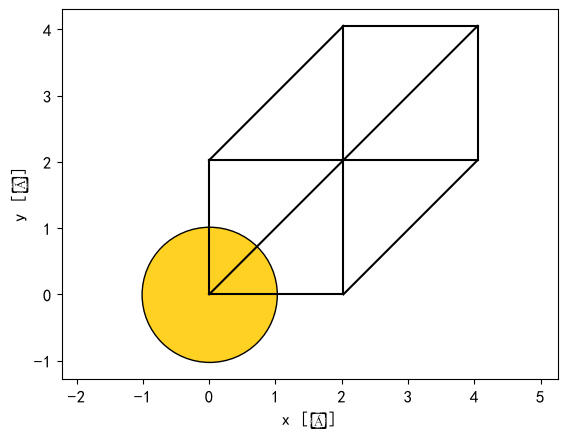

In [7]:
a=4.05
b=a/2
fcc=Atoms('Au', cell=[(0, b, b), (b, 0, b), (b, b, 0)], pbc=True)
abtem.show_atoms(fcc,plane='xy')

   Hydrogen wire:

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='y [Å]'>)

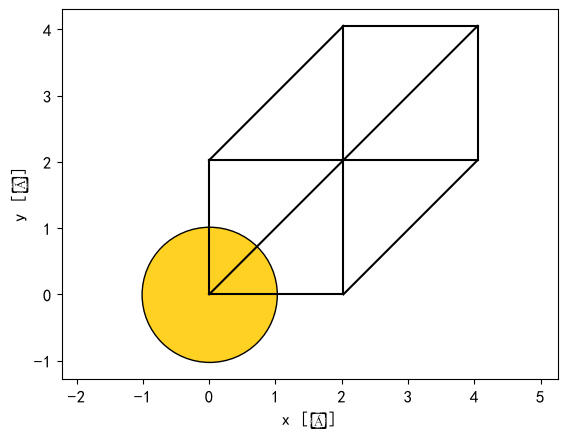

In [6]:
d = 0.9  # H-H distance
h = Atoms('H', positions=[(0, 0, 0)],  cell=(d, 0, 0),pbc=(1, 0, 0))
abtem.show_atoms(fcc,plane='xy')


此外 ase还提供了一套用来建模atoms的模块，叫做build，常用包含：

- bulk ：用了创建体系统。如果没提供具体的晶体结构和晶格长度将猜测获得。
- nanotube 
- surface
- surface_with_termination :根据给定晶格和密勒指数，创建具有指定终止面的表面（结构）
- general_surface:

- niggli :尼格利约化晶胞，为任意晶格找到唯一且规范表示。
- attach ：连接两种不同的atoms对象。
- 


SOURCE CODE: ase.build.surface

> Helper functions for creating the most common surfaces and related tasks.The helper functions can create the most common low-index surfaces,add vacuum layers and add adsorbates.

```python
def _all_surface_functions():
    # Convenient for debugging.
    d = {
        func.__name__: func
        for func in [
            fcc100,
            fcc110,
            bcc100,
            bcc110,
            bcc111,
            fcc111,
            hcp0001,
            hcp10m10,
            diamond100,
            diamond111,
            fcc111,
            mx2,
            graphene,
        ]
    }
    return d

```

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='y [Å]'>)

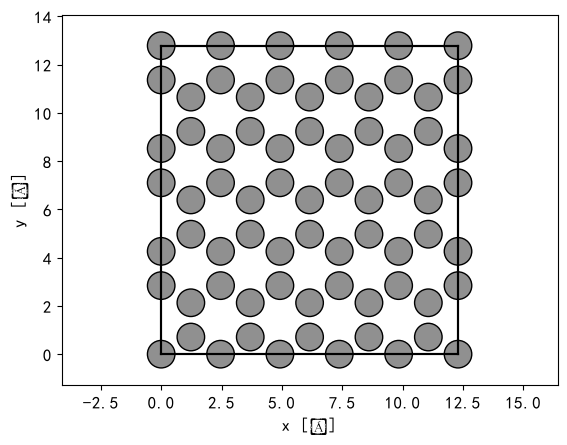

In [25]:
from ase.build.surface import graphene
atoms = graphene("C2", vacuum=2)
atoms=abtem.orthogonalize_cell(atoms)
atoms=atoms*(5,3,1)
abtem.show_atoms(atoms,show_periodic=True,plane='xy')

Original Cell: Cell([[0.0, 2.0, 2.0], [2.0, 0.0, 2.0], [2.0, 2.0, 0.0]])
Orthogonalized Cell: Cell([4.0, 4.0, 4.0])


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='y [Å]'>)

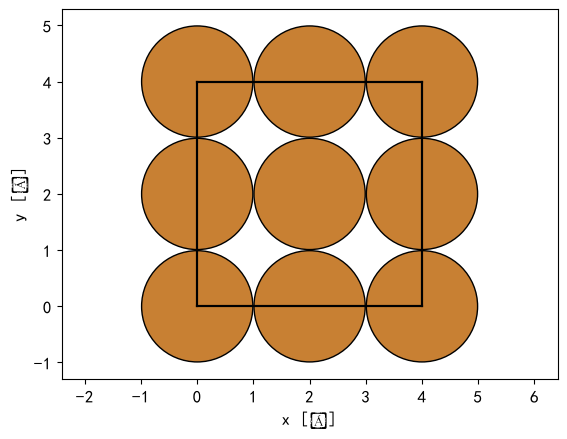

In [33]:
from ase.build.bulk import bulk
atoms = bulk('Cu', crystalstructure='fcc', a=4)
print(f"Original Cell: {atoms.cell}")
atoms=abtem.orthogonalize_cell(atoms)
print(f"Orthogonalized Cell: {atoms.cell}")
abtem.show_atoms(atoms,plane='xy',show_periodic=True)

## Atoms对象的属性

前面我们在创建atoms对象的时候就已经使用了传入atoms属性的方法，比如positions（位置的列表）,numbers(原子序数的列表)，symbols(符号列表)

In [ ]:
print(f"Numbers: {boxed_atoms.numbers}")
print(f"Positions: {boxed_atoms.positions}")
print(f"symbols: {boxed_atoms.symbols}")

##  可视化


### abtem.visualization.show_atoms()
SOURCE CODE: [visualization.py](..\abtem\visualize\visualizations.py#699)

#### error report 

show_periodic means make atoms on the boundary not be clipped by the periodlength，it works by setting a margin to allow those boundary-atoms be viewed.

visualization的 show_atoms() method now not supoort parameter 'show_periodic' when cell is not orthogonalized.Because fun:pad_atoms use:
```python
  reps[axis] = int(1 + 2 * np.ceil(margin / atoms.cell[axis, axis]))
```
it works on the preimier that cell are orthogonal that diag element are nonezero. if normal, it causes reps[axis]=3.

In [ ]:
a=4.05
b=a/2
fcc=Atoms('Au', cell=[(0, b, b), (b, 0, b), (b, b, 0)], pbc=True)
abtem.show_atoms(fcc,plane='xz', show_periodic=True)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='z [Å]'>)

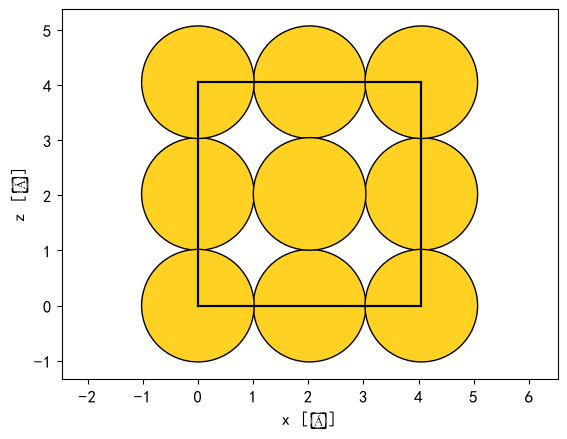

In [8]:
a=4.05
b=a/2
fcc=Atoms('Au', cell=[(0, b, b), (b, 0, b), (b, b, 0)], pbc=True)
fcc=abtem.orthogonalize_cell(fcc)
abtem.show_atoms(fcc,plane='xz', show_periodic=True)

### ase.visualize.view

In [ ]:
from ase.visualize import view

view(srtio3)

NameError: name 'srtio3' is not defined

> 如果在远程环境下工作，期望直接嵌入到notebook中显示，可以通过安装`nglview`（abtem中非默认依赖）来实现。这将让你使用nglview后端来实现viewfunction.

In [ ]:
view(srtio3, viewer='nglview')

## abtem提供的方法


### Orthogonalize_cell()

SOURCE CODE: [orthogonalize_cell()](../abtem/atoms.py#823)

基本工作流：

0.预处理
拷贝--》清除噪声，把极低的坐标分量归0.
  - --》origin分支将用户指定原点挪到（0,0,0）
  - --》plane分支将原子集合旋转到指定平面，后续处理默认z方向为束流。

1.cell尺寸确定
  - --》box is none,使用best_orthogonal_cell()
  - --》box传入时，直接调用。

2.早退路径

触发条件是对角元与 box 精确相等(tuole(np.diag(cell))==tuple(box))
  - --》is_cell_orthogonal()通过时，直接返回，报告transform为恒等。
  - --》近似正交时（非对角元残留~1e-16）

3.主路径
   - C1：任意格矢长度<tolerance导致报错。
   - C2：边界吸附（0/1分数坐标边界 \pm 0.01AA的原子钉到整数值）
   - C3: box乘以inv(cell)获得当前胞的分数系数，四舍五入后
   - C4:解仿射矩阵：把晶胞精确映射到正交盒子中。
   - C5：allow_transform分支，只有==True时才施加仿射变换（坐标：position@A,晶胞：diag(box)）
   - C6:返回格式，return_transform优先return_transform_matrix


```python
def orthogonalize_cell(
    atoms: Atoms,
    max_repetitions: int = 5,
    return_transform: bool = False,
    return_transform_matrix: bool = False,
    allow_transform: bool = True,
    plane: str | tuple[tuple[float, float, float], tuple[float, float, float]] = "xy",
    origin: tuple[float, float, float] = (0.0, 0.0, 0.0),
    box: tuple[float, float, float] | None = None,
    tolerance: float = 0.01,
)
```

atoms.cell: Cell([[3.18, 0.0, 0.0], [-1.59, 2.753960784034515, 0.0], [0.0, -0.0, 7.1899999999999995]])


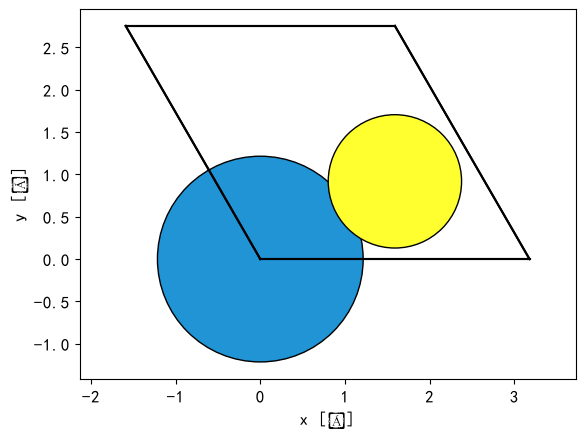

In [9]:
from ase import symbols
from ase.build.surface import mx2
atoms = mx2("WS2", vacuum=2)
abtem.show_atoms(atoms)
print(f"atoms.cell: {atoms.cell}")


Transform: (array([ 0., -0.,  0.]), array([1., 1., 1.]), array([0., 0., 0.]))
Cell: Cell([3.18, 5.50792156806903, 7.1899999999999995])
Numbers: 6
Positions: 6


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='y [Å]'>)

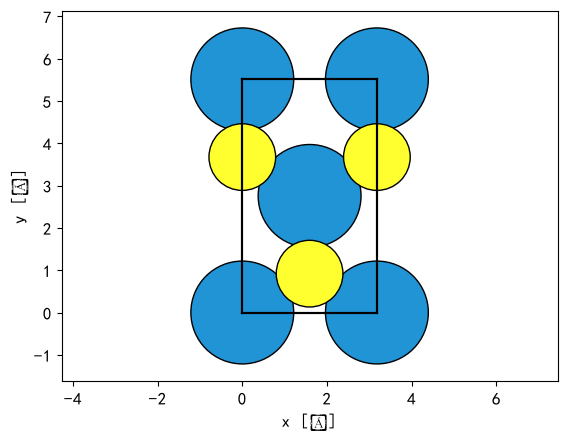

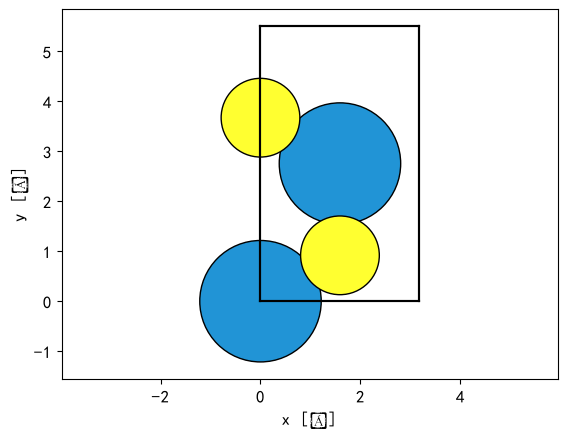

In [16]:
orth_atoms,transform = abtem.orthogonalize_cell(atoms,return_transform=True,box=None)
abtem.show_atoms(orth_atoms,show_periodic=True)
print(f"Transform: {transform}")
print(f"Cell: {orth_atoms.cell}")
print(f"Numbers: {orth_atoms.numbers.__len__()}")
print(f"Positions: {orth_atoms.positions.__len__()}")
abtem.show_atoms(orth_atoms)

Transform: (array([ 0.        , -0.        , -0.08229234]), array([1.05177735, 1.0339559 , 0.69541029]), array([-0.08108108,  0.        ,  0.        ]))
Cell: Cell([20.0, 20.0, 5.0])
Numbers: 126
Positions: 126


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='y [Å]'>)

d:\miniforge\envs\abtem\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 197 (\N{LATIN CAPITAL LETTER A WITH RING ABOVE}) missing from font(s) SimHei.
  func(*args, **kwargs)
d:\miniforge\envs\abtem\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 197 (\N{LATIN CAPITAL LETTER A WITH RING ABOVE}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


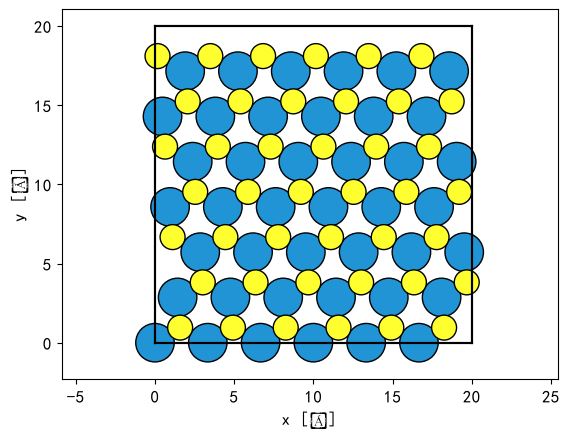

In [15]:
boxed_atoms,transform = abtem.orthogonalize_cell(atoms,return_transform=True,box=[20,20,5])
print(f"Transform: {transform}")
print(f"Cell: {boxed_atoms.cell}")
print(f"Numbers: {boxed_atoms.numbers.__len__()}")
print(f"Positions: {boxed_atoms.positions.__len__()}")
abtem.show_atoms(boxed_atoms)

In [75]:
import numpy as np
max_repetitions = 2
if isinstance(max_repetitions, int):
     max_repetitions = (max_repetitions,) * 3

assert isinstance(max_repetitions, tuple)

nx = np.arange(-max_repetitions[0], max_repetitions[0] + 1)
ny = np.arange(-max_repetitions[1], max_repetitions[1] + 1)
nz = np.arange(-max_repetitions[2], max_repetitions[2] + 1)
a=np.array([1,-1,0])
b=np.array([1,1,0])
c=np.array([0,0,1])
cell=np.array([a,b,c])
print(f"original cell: {cell}")
vectors = np.abs(
        (
            (nx[:, None] * a[None])[:, None, None]
            + (ny[:, None] * b[None])[None, :, None]
            + (nz[:, None] * c[None])[None, None, :]
        )
    )
print(f"vectors shape: {vectors.shape}")
print(f"example vectors: {vectors[0,0,0]}, {vectors[1,1,0]}, {vectors[0,1,0]}, {vectors[0,0,1]}")

original cell: [[ 1 -1  0]
 [ 1  1  0]
 [ 0  0  1]]
vectors shape: (5, 5, 5, 3)
example vectors: [4 0 2], [2 0 2], [3 1 2], [4 0 1]


In [77]:
eps=1e-6
norm = np.linalg.norm(vectors, axis=-1) #norm dim=3
nonzero = norm > eps
norm[nonzero == 0] = eps
new_vectors = []
for i in range(3):
        angles = vectors[..., i] / norm ## cos余弦值矩阵（dim=3），越小越接近正交，越大越接近平行
        small_angles = np.abs(angles.max() - angles < eps) #粗筛出一批满足条件的基矢

        small_angles = np.where(small_angles * nonzero)#排除掉零向量的情况，返回满足条件的索引
        print(small_angles)
        print(f"small_angles indices for axis {i}: {small_angles}")
        print(vectors[small_angles])
        print(np.linalg.norm(vectors[small_angles], axis=1))
        shortest_small_angles = np.argmin(np.linalg.norm(vectors[small_angles], axis=1))#找出最短的基矢
        print(f"shortest_small_angles index for axis {i}: {shortest_small_angles}")
        print("shape of small_angles[0]:", small_angles[0].shape)
        new_vector = np.array(
            [
                nx[small_angles[0][shortest_small_angles]],
                ny[small_angles[1][shortest_small_angles]],
                nz[small_angles[2][shortest_small_angles]],
            ]
        )
        new_vector = np.sign(np.dot(new_vector, cell)[i]) * new_vector 
        new_vectors.append(new_vector)
        print(f"filtered_new_vector for basis vector {i} in original's basis: {new_vector}")
        print("=========")
cell = np.dot(new_vectors, np.array(cell))
print(f"cell: {cell}")
print(f"norm: {np.linalg.norm(cell, axis=0)}")

(array([0, 1, 3, 4]), array([0, 1, 3, 4]), array([2, 2, 2, 2]))
small_angles indices for axis 0: (array([0, 1, 3, 4]), array([0, 1, 3, 4]), array([2, 2, 2, 2]))
[[4 0 0]
 [2 0 0]
 [2 0 0]
 [4 0 0]]
[4. 2. 2. 4.]
shortest_small_angles index for axis 0: 1
shape of small_angles[0]: (4,)
filtered_new_vector for basis vector 0 in original's basis: [1 1 0]
(array([0, 1, 3, 4]), array([4, 3, 1, 0]), array([2, 2, 2, 2]))
small_angles indices for axis 1: (array([0, 1, 3, 4]), array([4, 3, 1, 0]), array([2, 2, 2, 2]))
[[0 4 0]
 [0 2 0]
 [0 2 0]
 [0 4 0]]
[4. 2. 2. 4.]
shortest_small_angles index for axis 1: 1
shape of small_angles[0]: (4,)
filtered_new_vector for basis vector 1 in original's basis: [-1  1  0]
(array([2, 2, 2, 2]), array([2, 2, 2, 2]), array([0, 1, 3, 4]))
small_angles indices for axis 2: (array([2, 2, 2, 2]), array([2, 2, 2, 2]), array([0, 1, 3, 4]))
[[0 0 2]
 [0 0 1]
 [0 0 1]
 [0 0 2]]
[2. 1. 1. 2.]
shortest_small_angles index for axis 2: 1
shape of small_angles[0]: (4,)
filter